# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Najwa Namira Zaneti]
- **Email:** [zaneti951@gmail.com]
- **ID Dicoding:** [CDCC009DX1602]

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Seberapa besar pengaruh kondisi cuaca (weathersit, temp, hum, windspeed) terhadap jumlah penyewaan sepeda (cnt) pada hari kerja dibandingkan hari libur selama tahun 2011–2012?

SMART:

Specific: Fokus pada variabel cuaca + perbandingan hari kerja vs libur

Measurable: Bisa pakai korelasi, regresi, atau feature importance

Action-Oriented: Bisa bantu operator menentukan strategi saat cuaca buruk

Relevant: Cuaca = faktor utama di dataset

Time-bound: Tahun 2011–2012
- **Pertanyaan 2:** Pada jam berapa (hr) terjadi puncak penyewaan sepeda (cnt) dan bagaimana perbedaannya antara pengguna casual dan registered selama hari kerja di tahun 2012?

SMART:

Specific: Fokus ke jam (hr), tipe user (casual vs registered)

Measurable: Peak hour (nilai maksimum cnt)

Action-Oriented: Bisa optimasi distribusi sepeda

Relevant: Penting untuk operasional bike sharing

Time-bound: Tahun 2012

## Import Semua Packages/Library yang Digunakan
Melakukan import library Python yang diperlukan untuk mendukung seluruh proses analisis data, mulai dari manipulasi data hingga pembuatan dashboard interaktif. Berikut adalah daftar library yang digunakan:

**Manipulasi Data:**

- pandas: untuk pengolahan data tabular (Dataframe)

- numpy: untuk komputasi saintifik dan operasi matriks atau array multidimensi.

**Visualisasi Data:**

- matplotlib.pyplot: membuat visualisasi statis seperti grafik batang, garis, dan pie chart.

- seaborn: untuk menghasilkan visualisasi data statistik yang lebih menarik secara estetika dan informatif.

**Manajemen Waktu:**

- datetime (dt): untuk mengolah kolom yang berkaitan dengan waktu, seperti mengubah format string menjadi tipe data datetime untuk analisis time series.

**Dashboard Interaktif:**

- streamlit: Framework utama yang digunakan untuk membangun dashboard analisis data secara cepat dan interaktif agar hasil temuan data dapat dikomunikasikan dengan lebih baik.

In [2]:

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date handling
import datetime as dt

# Dashboard
!pip install streamlit
import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 67.1 MB/s eta 0:00:00


## Data Wrangling

Pada tahap ini dilakukan proses pengumpulan data dari dataset Bike Sharing yang terdiri dari data harian (day.csv) dan data per jam (hour.csv). Data kemudian dimuat ke dalam DataFrame menggunakan library pandas.

In [3]:
import pandas as pd

# menentukan path dataset
hour_path = '/content/drive/MyDrive/DICODING DBS/proyek analisis data/Bike-sharing-dataset/hour.csv'
day_path = '/content/drive/MyDrive/DICODING DBS/proyek analisis data/Bike-sharing-dataset/day.csv'

# cek apakah file bisa diakses
print("Path hour.csv:", hour_path)
print("Path day.csv :", day_path)

Path hour.csv: /content/drive/MyDrive/DICODING DBS/proyek analisis data/Bike-sharing-dataset/hour.csv
Path day.csv : /content/drive/MyDrive/DICODING DBS/proyek analisis data/Bike-sharing-dataset/day.csv


#### Load df ...
**hour_df**: Berisi data penyewaan sepeda yang dicatat secara per jam.

**day_df**: Berisi data penyewaan sepeda yang dicatat secara harian.

Tujuan:
Memastikan seluruh data berhasil terbaca dengan benar ke dalam Dataframe.

In [4]:
hour_df = pd.read_csv(hour_path)
day_df = pd.read_csv(day_path)

# tampilkan data
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Penyewaan sepeda sangat rendah pada jam malam hingga dini hari (0–4), menunjukkan aktivitas pengguna minim pada waktu tersebut.
- Pengguna registered jauh lebih banyak dibandingkan casual, menandakan bike sharing lebih sering digunakan untuk kebutuhan rutin.

### Assessing Data
Proses mengumpulkan, memeriksa, dan mengevaluasi informasi untuk memahami kinerja, kondisi, atau kualitas subjek/objek tertentu.

Tujuannya adalah menghasilkan insight atau diagnosis untuk perbaikan dan pengambilan keputusan berbasis data.

#### Identifying 4 problem
Bertujuan untuk mengidentifikasi empat masalah utama pada dataset

- Struktur & Tipe Data: Memastikan setiap kolom memiliki tipe data yang sesuai untuk proses analisis.

- Missing Values: Mendeteksi keberadaan data kosong yang dapat mengganggu akurasi perhitungan.

- Duplicate Data: Menjamin integritas data dengan memastikan tidak ada informasi yang berulang.

- Outliers & Statistik Deskriptif: Meninjau distribusi data untuk menemukan nilai-nilai anomali yang dapat memengaruhi model statistik.

In [5]:
# cek informasi dataset
print("INFO DATA")
print(hour_df.info())

# cek missing value
print("\nMISSING VALUE")
print(hour_df.isnull().sum())

# cek duplicate data
print("\nDUPLICATE DATA")
print(hour_df.duplicated().sum())

# statistik deskriptif (untuk deteksi outlier)
print("\nSTATISTIK DESKRIPTIF")
print(hour_df.describe())

INFO DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None

MISSING VALUE
instant       0
dte

**Steps to Take:**
- Tidak perlu menangani missing value karena dataset tidak memiliki data kosong.

- Melakukan transformasi pada variabel kategorikal seperti season dan weathersit agar lebih mudah dipahami pada tahap analisis berikutnya.

**Insight:** (Opsional)
- Dataset tidak memiliki missing value maupun data duplikat.

- Terdapat potensi outlier pada variabel cnt yang menunjukkan variasi jumlah penyewaan yang cukup besar.


### Cleaning Data
Proses mengidentifikasi, memperbaiki, atau menghapus data yang tidak akurat dalam sebuah dataset. Proses ini bertujuan untuk memastikan data yang digunakan dalam analisis, machine learning, atau pengambilan keputusan berkualitas tinggi

#### Fixing 3 problem
Perbaikan terhadap tiga masalah utama yang ditemukan selama proses penilaian data:

Data Duplikat: Menghapus baris identik menggunakan drop_duplicates().

Data Transformation (Mapping): Mengubah nilai numerik pada kolom season dan weathersit menjadi label kategori yang lebih informatif.

Penanganan Outliers: Menggunakan metode Interquartile Range (IQR) untuk mengidentifikasi dan memfilter pencilan pada kolom cnt. Bertujuan untuk menghasilkan model analisis yang lebih stabil dan akurat.

In [7]:
# 1. Menangani duplicate
hour_df = hour_df.drop_duplicates()

# 2. Definisi Map (Sekali saja)
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain/Snow', 4: 'Heavy Rain'}


df_work = hour_df.copy()
df_work['season'] = df_work['season'].replace(season_map)
df_work['weathersit'] = df_work['weathersit'].replace(weather_map)

# 3. Menangani outlier pada kolom 'cnt'
Q1 = df_work['cnt'].quantile(0.25)
Q3 = df_work['cnt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data
hour_df_cleaned = df_work[
    (df_work['cnt'] >= lower_bound) &
    (df_work['cnt'] <= upper_bound)
].copy()

# Cek hasil
print(f"Data asli: {hour_df.shape}")
print(f"Data bersih (tanpa outlier): {hour_df_cleaned.shape}")
print("\nContoh data hasil mapping:")
print(hour_df_cleaned[['season', 'weathersit']].head())

Data asli: (17379, 17)
Data bersih (tanpa outlier): (16874, 17)

Contoh data hasil mapping:
   season weathersit
0  Spring      Clear
1  Spring      Clear
2  Spring      Clear
3  Spring      Clear
4  Spring      Clear


**Insight:** (Opsional)
- Data tidak memiliki duplikasi signifikan, sehingga proses pembersihan lebih difokuskan pada transformasi dan penanganan outlier.

- Setelah handling outlier pada variabel cnt, jumlah data berkurang sehingga distribusi data menjadi lebih stabil untuk analisis selanjutnya.

## Exploratory Data Analysis (EDA)
Bertujuan untuk mengeksplorasi dataset untuk memahami karakteristik data hingga menjawab pertanyaan riset melalui pendekatan statistik deskriptif. Fokus utama pada tahap ini adalah melihat bagaimana distribusi penyewaan sepeda dipengaruhi oleh variabel waktu dan kondisi lingkungan.

### Explore
Pertanyaan 1: Pengaruh Cuaca vs Hari Kerja
Pada bagian ini, dilakukan eksplorasi untuk memahami bagaimana kondisi cuaca memengaruhi minat penyewa pada hari kerja dibandingkan hari libur. Hal ini penting untuk strategi manajemen armada di berbagai kondisi cuaca.

Pertanyaan 2: Performa Jam Operasional & Segmentasi Pengguna (2012)
Fokus eksplorasi ini adalah mengidentifikasi jam-jam sibuk pada tahun 2012. Dengan membedah data pengguna Casual dan Registered, kita dapat melihat perbedaan motivasi penggunaan sepeda (apakah untuk komuter atau sekadar rekreasi).

In [8]:
# PERTANYAAN 1
# rata-rata penyewaan berdasarkan cuaca dan status hari
weather_analysis = hour_df.groupby(['weathersit', 'workingday'])['cnt'].mean().reset_index()

weather_analysis

# PERTANYAAN 2
# filter tahun 2012
data_2012 = hour_df[hour_df['yr'] == 1]
# rata-rata berdasarkan jam
hour_analysis = data_2012.groupby('hr')[['casual', 'registered', 'cnt']].mean()
hour_analysis

,casual,registered,cnt
hr,,,
0,10.827397,53.802740,64.630137
1,7.247253,32.879121,40.126374
2,5.074380,21.622590,26.696970
3,2.645070,10.687324,13.332394
4,1.230556,6.022222,7.252778
5,1.604396,23.406593,25.010989
6,4.505495,89.810440,94.315934
7,11.728022,255.417582,267.145604
8,24.153846,430.609890,454.763736


**Insight:** (Opsional)
- Kondisi cuaca cerah menghasilkan rata-rata penyewaan sepeda lebih tinggi dibandingkan cuaca buruk, baik pada hari kerja maupun hari libur.

- Penyewaan sepeda meningkat pada jam sibuk (pagi dan sore), dengan pengguna registered selalu mendominasi dibandingkan casual di tahun 2012.

## Visualization & Explanatory Analysis
Bertujuan untuk menjawab pertanyaan riset yang telah ditetapkan sebelumnya melalui representasi visual. Visualisasi yang baik akan memudahkan dalam mengidentifikasi tren, pola, dan hubungan antar variabel dalam dataset Bike Sharing.

### Pertanyaan 1: Seberapa besar pengaruh kondisi cuaca (weathersit, temp, hum, windspeed) terhadap jumlah penyewaan sepeda (cnt) pada hari kerja dibandingkan hari libur selama tahun 2011–2012?”


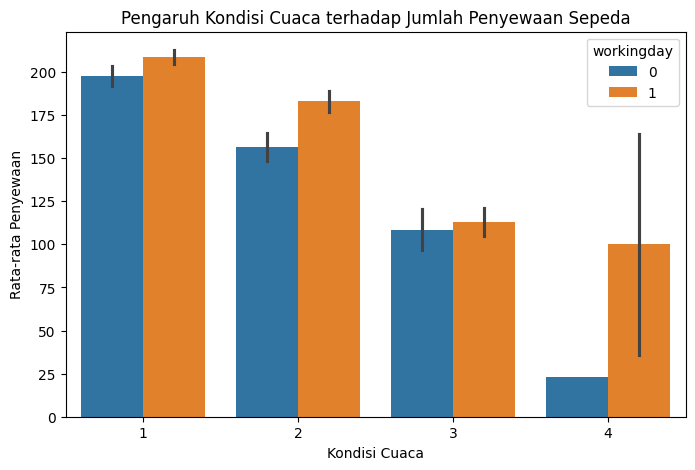

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=hour_df,
    x='weathersit',
    y='cnt',
    hue='workingday'
)

plt.title('Pengaruh Kondisi Cuaca terhadap Jumlah Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

### Pertanyaan 2: Pada jam berapa (hr) terjadi puncak penyewaan sepeda (cnt) dan bagaimana perbedaannya antara pengguna casual dan registered selama hari kerja di tahun 2012?

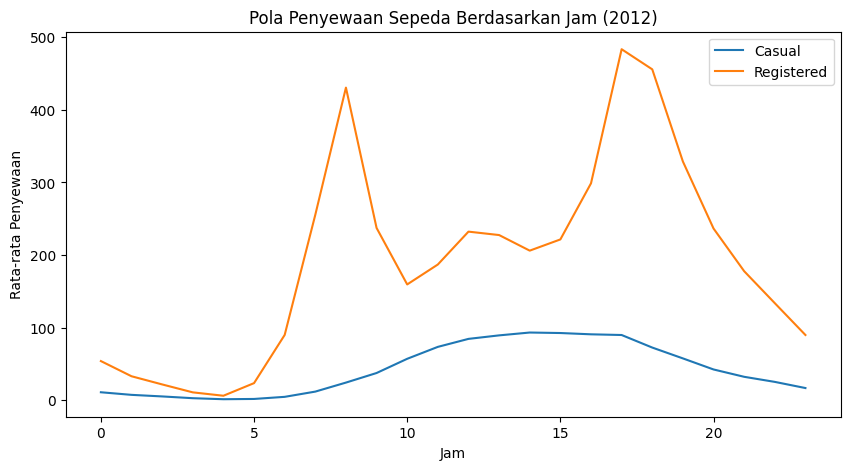

In [10]:
# filter tahun 2012
data_2012 = hour_df[hour_df['yr'] == 1]

hour_group = data_2012.groupby('hr')[['casual', 'registered']].mean()

plt.figure(figsize=(10,5))

plt.plot(hour_group.index, hour_group['casual'], label='Casual')
plt.plot(hour_group.index, hour_group['registered'], label='Registered')

plt.title('Pola Penyewaan Sepeda Berdasarkan Jam (2012)')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.legend()
plt.show()

**Insight:** (Opsional)
- Cuaca cerah menghasilkan jumlah penyewaan tertinggi baik pada hari kerja maupun hari libur, sedangkan kondisi cuaca buruk menurunkan jumlah penyewaan secara signifikan.

- Penyewaan sepeda mencapai puncak pada jam sibuk (pagi dan sore), dengan pengguna registered selalu lebih tinggi dibandingkan pengguna casual pada tahun 2012.

## Analisis Lanjutan (Opsional)
Manual Clustering Berdasarkan Kategori Suhu (Binning)
Tujuan: Mengetahui pada rentang suhu mana (Cold, Normal, Hot) pengguna paling banyak menyewa sepeda.

Insight: Berdasarkan grafik di bawah, terlihat bahwa penyewaan mencapai puncaknya pada kategori suhu Normal atau Hot, sedangkan pada suhu Cold terjadi penurunan signifikan. Hal ini menunjukkan cuaca dingin menjadi penghambat pengguna untuk bersepeda.

/tmp/ipykernel_2299/3915031443.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


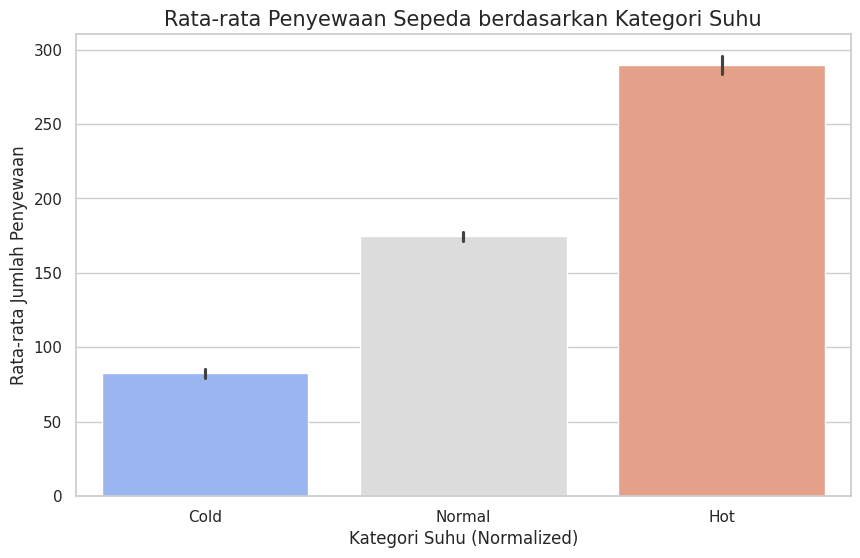

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid")

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(
    x='temp_category',
    y='cnt',
    data=hour_df_cleaned,
    estimator='mean',
    palette='coolwarm'
)

plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kategori Suhu', fontsize=15)
plt.xlabel('Kategori Suhu (Normalized)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca sangat memengaruhi jumlah penyewaan sepeda, di mana cuaca cerah menghasilkan jumlah penyewaan tertinggi baik pada hari kerja maupun hari libur, sedangkan cuaca buruk menyebabkan penurunan signifikan.

- **Conclusion pertanyaan 2:** Penyewaan sepeda paling tinggi terjadi pada jam sibuk (pagi dan sore), dengan pengguna registered mendominasi dibandingkan pengguna casual pada tahun 2012.

**Rekomendasi Action Item:**
- Menambah jumlah armada sepeda pada jam sibuk (07–09 dan 17–19) untuk mengantisipasi lonjakan permintaan dari pengguna registered.

- Menyusun strategi promosi atau insentif pada kondisi cuaca buruk agar tingkat penyewaan tetap stabil meskipun terjadi penurunan minat pengguna.

In [14]:
from google.colab import files
files.download('main_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>